In [1]:
import sys,os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import functions2 as f2
import fx_hedges.fxshort_gates
importlib.reload(fx_hedges.fxshort_gates)
importlib.reload(f2)

<module 'functions2' from '/Users/alexwebb/laptop_coding/risk_matrix/functions2.py'>

++++ get_seriesULVR.LSE
sort_cols: ohlc not set. True only needd for ATR calculations for vol stops. Defaulting to False


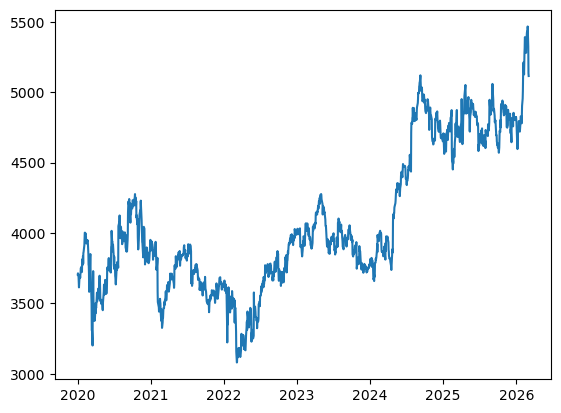

In [7]:
ticker='ULVR.LSE'
s=f2.get_series(ticker, window_start='2020-01-02')
plt.plot(s)

++++ get_seriesULVR.LSE
sort_cols: ohlc not set. True only needd for ATR calculations for vol stops. Defaulting to False
slope diff (fit - np): -1.962405932198763e-17
intercept diff (fit - np): 3.552713678800501e-15


/var/folders/mp/2szq6ct92zl4hbdd0y18rqyw0000gn/T/ipykernel_47472/1047728402.py:40: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(idx, yhat, color='crimson', lw=2, label='OLS fit (log)', zorder=5)


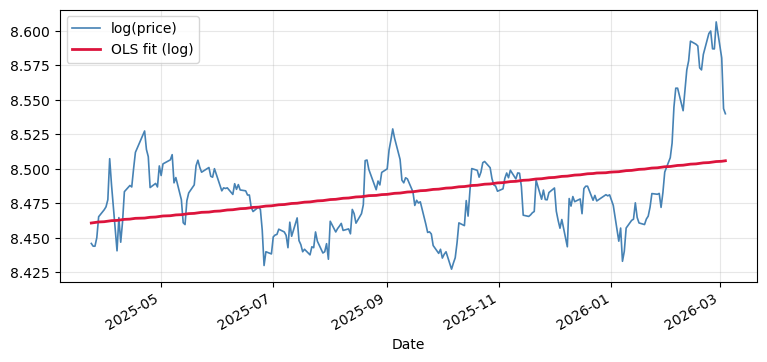

/var/folders/mp/2szq6ct92zl4hbdd0y18rqyw0000gn/T/ipykernel_47472/1047728402.py:47: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(idx, p_hat, color='crimson', lw=2, label='OLS fit (price)', zorder=5)


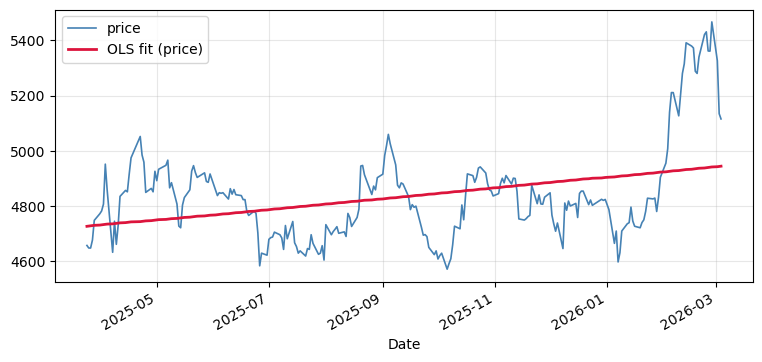

In [ ]:
import sys, os, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import functions2 as f2
import fx_hedges.fxshort_gates
importlib.reload(fx_hedges.fxshort_gates)
importlib.reload(f2)

# 1) Load data
ticker = 'ULVR.LSE'
s = f2.get_series(ticker, window_start='2020-01-02')

# 2) Choose window on clean log series
log_s = np.log(s).dropna()
w = min(240, len(log_s))   # change 60 -> any window you want
# y = log_s
y = log_s
idx = y.index
x = np.arange(len(y), dtype=float)

# 3) OLS via numpy (core OLS)
b1_np, b0_np = np.polyfit(x, y.values, 1)   # slope, intercept
yhat = b0_np + b1_np * x

# 4) Verify against rolling_ols_fit for the same window
fit = fx_hedges.fxshort_gates.rolling_ols_fit(log_s, w)
last_idx = log_s.index[-1]
b1_fit = float(fit.loc[last_idx, 'slope'])
b0_fit = float(fit.loc[last_idx, 'intercept'])

print("slope diff (fit - np):", b1_fit - b1_np)
print("intercept diff (fit - np):", b0_fit - b0_np)

# 5) Plot in log space
fig, ax = plt.subplots(figsize=(9,4))
y.plot(ax=ax, color='steelblue', lw=1.2, label='log(price)')
ax.plot(idx, yhat, color='crimson', lw=2, label='OLS fit (log)', zorder=5)
ax.legend(); ax.grid(True, alpha=0.3); plt.show()

# 6) Optional: plot in price space
p_hat = np.exp(yhat)
fig, ax = plt.subplots(figsize=(9,4))
s.loc[idx].plot(ax=ax, color='steelblue', lw=1.2, label='price')
ax.plot(idx, p_hat, color='crimson', lw=2, label='OLS fit (price)', zorder=5)
ax.legend(); ax.grid(True, alpha=0.3); plt.show()

In [4]:
# 